# To alinged SN2 and SN1 maps relative to SN3 using alignment parameter
## It conserves the flux...

In [1]:
import orb as orb
from orcs.process import SpectralCube
import logging
import json

import numpy as np
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.stats import sigma_clipped_stats
from lmfit import minimize, Parameters

from astropy.io import fits
from astropy.table import QTable
from astropy.table import Table

from astropy.modeling import models, fitting
from IPython.utils import io

from IPython.display import clear_output
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree
from scipy.spatial import distance
from scipy.ndimage import map_coordinates
from skimage.transform import AffineTransform, warp

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Definitions

In [2]:

def ensure_little_endian(array):
   if array.dtype.byteorder == '>':  # Big-endian
       return array.byteswap().newbyteorder()
   elif array.dtype.byteorder == '=' and not array.dtype.isnative:
       # '=' indique la compatibilité avec le système, mais vérifions si c'est native
       return array.byteswap().newbyteorder()
   else:
       return array
       
def aligmap(solution,hdr,folder,filejason_in,fileout):
    filetoalig = fits.getdata(data_paths_dict[filejason_in])
    filetoalig = ensure_little_endian(filetoalig)
    filealig   = warp(filetoalig, inverse_map=solution.inverse, mode='constant', cval=0) 
    filejason_out = filejason_in+'_alig'
    with open(jsonfile, 'r') as file: data = json.load(file)
    data[filejason_out] = folder+fileout
    with open(jsonfile, 'w') as file: json.dump(data, file, indent=4)
    print('In json :', filejason_out, '=', folder+fileout)
    fits.writeto(folder+fileout, filealig, hdr, overwrite=True)
    print('New fits:',folder+fileout)
    imout = fits.getdata(folder+fileout)
    return(imout)


def makeplot(codelog,codecmap,imagein,imagevvi,x1,x2,y1,y2,alp,vvimin,vvimax):
    plt.rcParams['axes.linewidth'] = 2
    plt.tick_params(axis='both', direction='out', labelsize=10, length=6, width=2)
    plt.axis([x1,x2,y1,y2])
    cmapp = 'gray'
    if codecmap == 1: cmapp = 'rainbow' 
    if codecmap == 2: cmapp = 'Greys' 
    if codelog == 0 :
        vvi = imagevvi[y1:y2,x1:x2]
        plt.imshow(imagein, cmap=cmapp, origin='lower',alpha=alp,
                                   vmin=np.nanpercentile(vvi,vvimin),
                                   vmax=np.nanpercentile(vvi,vvimax)) 
    if codelog == 1 :
        vvi = np.log10(imagevvi[y1:y2,x1:x2])
        plt.imshow(np.log10(imagein), cmap=cmapp, origin='lower',alpha=alp, 
                   vmin=np.nanpercentile(vvi,vvimin),vmax=np.nanpercentile(vvi,vvimax)) 
    if codelog == 2 :
        plt.imshow(imagein, cmap=cmapp, origin='lower',alpha=alp,vmin=vvimin,vmax=vvimax) 
    cbar = plt.colorbar(pad=0.01)
    cbar.ax.tick_params(labelsize=10)
    plt.xlabel('X',size=10)
    plt.ylabel('Y',size=10) 
    return




### Data

In [3]:

jsonfile = '../data.json'
data_paths_dict = json.load(open(jsonfile))

In [4]:
#header for new files  will be from deepframe_SN3, unless...
imdeep3,hdrdeep3 = fits.getdata(data_paths_dict['deepframe_SN3'],header=True)
imdeep2,hdrdeep2 = fits.getdata(data_paths_dict['deepframe_SN2'],header=True)
imdeep1,hdrdeep1 = fits.getdata(data_paths_dict['deepframe_SN1'],header=True)

# Read alignement parameters
aligsol_SN1 = data_paths_dict['parametres_align_SN1']
print('Alignement solution SN1:')
print(aligsol_SN1)
aligsol_SN1_transform = AffineTransform(matrix=np.array(aligsol_SN1))
print()

aligsol_SN2 = data_paths_dict['parametres_align_SN2']
print('Alignement solution SN2:')
print(aligsol_SN2)
aligsol_SN2_transform = AffineTransform(matrix=np.array(aligsol_SN2))



Alignement solution SN1:
[[0.9996452901852847, 0.0009589236323867007, -0.15212490111707666], [-0.0006738528519752424, 0.9995337869965651, 3.0336756657991373], [0.0, 0.0, 1.0]]

Alignement solution SN2:
[[1.0005395994515391, 0.0008638597780196547, -2.206579671118334], [-0.0008216187199730986, 1.0004252644585858, 1.745832037531727], [0.0, 0.0, 1.0]]


# Shift SN1 and SN2 maps so they can be compared to SN3

In [7]:
# for deep, continuum, flux and err 

    
gogo = 'yes'   #Done 31 oct. 25

if gogo == 'yes':
# SN1:
    alsol    = aligsol_SN1_transform
    header   = hdrdeep3
    folder   = '/users/carmellerobert/Desktop/NGC4490/1-DATA/'
    imdeep1_alig      = aligmap(alsol,header,folder,'deepframe_SN1',    'NGC4490-SN1Deep_Aligned.fits')
    imcont1_alig      = aligmap(alsol,header,folder,'continuum_SN1',    'NGC4490-SN1Continuum_Aligned.fits')
    imcont1_err_alig  = aligmap(alsol,header,folder,'continuum_SN1_err','NGC4490-SN1Continuum_err_Aligned.fits')
    imfluxo2_alig     = aligmap(alsol,header,folder,'flux_OII3727',     'NGC4490-OII3727flux_Aligned.fits')
    imfluxo2_err_alig = aligmap(alsol,header,folder,'flux_OII3727_err', 'NGC4490-OII3727flux_err_Aligned.fits'    )

    print()
# SN2:
    alsol    = aligsol_SN2_transform
    header = hdrdeep3
    folder='/users/carmellerobert/Desktop/NGC4490/1-DATA/'
    imdeep2_alig       = aligmap(alsol,header,folder,'deepframe_SN2',    'NGC4490-SN2Deep_Aligned.fits')
    imcont2_alig       = aligmap(alsol,header,folder,'continuum_SN2',    'NGC4490-SN2Continuum_Aligned.fits')
    imcont2_err_alig   = aligmap(alsol,header,folder,'continuum_SN2_err','NGC4490-SN2Continuum_err_Aligned.fits')
    imfluxhb_alig      = aligmap(alsol,header,folder,'flux_Hbeta',       'NGC4490-Hbflux_Aligned.fits')
    imfluxhb_err_alig  = aligmap(alsol,header,folder,'flux_Hbeta_err',   'NGC4490-Hbflux_err_Aligned.fits')
    imfluxo3_alig      = aligmap(alsol,header,folder,'flux_OIII5007',    'NGC4490-OIII5007flux_Aligned.fits')
    imfluxo3_err_alig  = aligmap(alsol,header,folder,'flux_OIII5007_err','NGC4490-OIII5007flux_err_Aligned.fits'    )    

    print('Done')

In json : deepframe_SN1_alig = /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-SN1Deep_Aligned.fits
New fits: /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-SN1Deep_Aligned.fits
In json : continuum_SN1_alig = /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-SN1Continuum_Aligned.fits
New fits: /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-SN1Continuum_Aligned.fits
In json : continuum_SN1_err_alig = /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-SN1Continuum_err_Aligned.fits
New fits: /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-SN1Continuum_err_Aligned.fits
In json : flux_OII3727_alig = /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-OII3727flux_Aligned.fits
New fits: /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-OII3727flux_Aligned.fits
In json : flux_OII3727_err_alig = /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-OII3727flux_err_Aligned.fits
New fits: /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-OII3727flux_err_Aligned.fi

Text(0.5, 1.0, 'Height3/1')

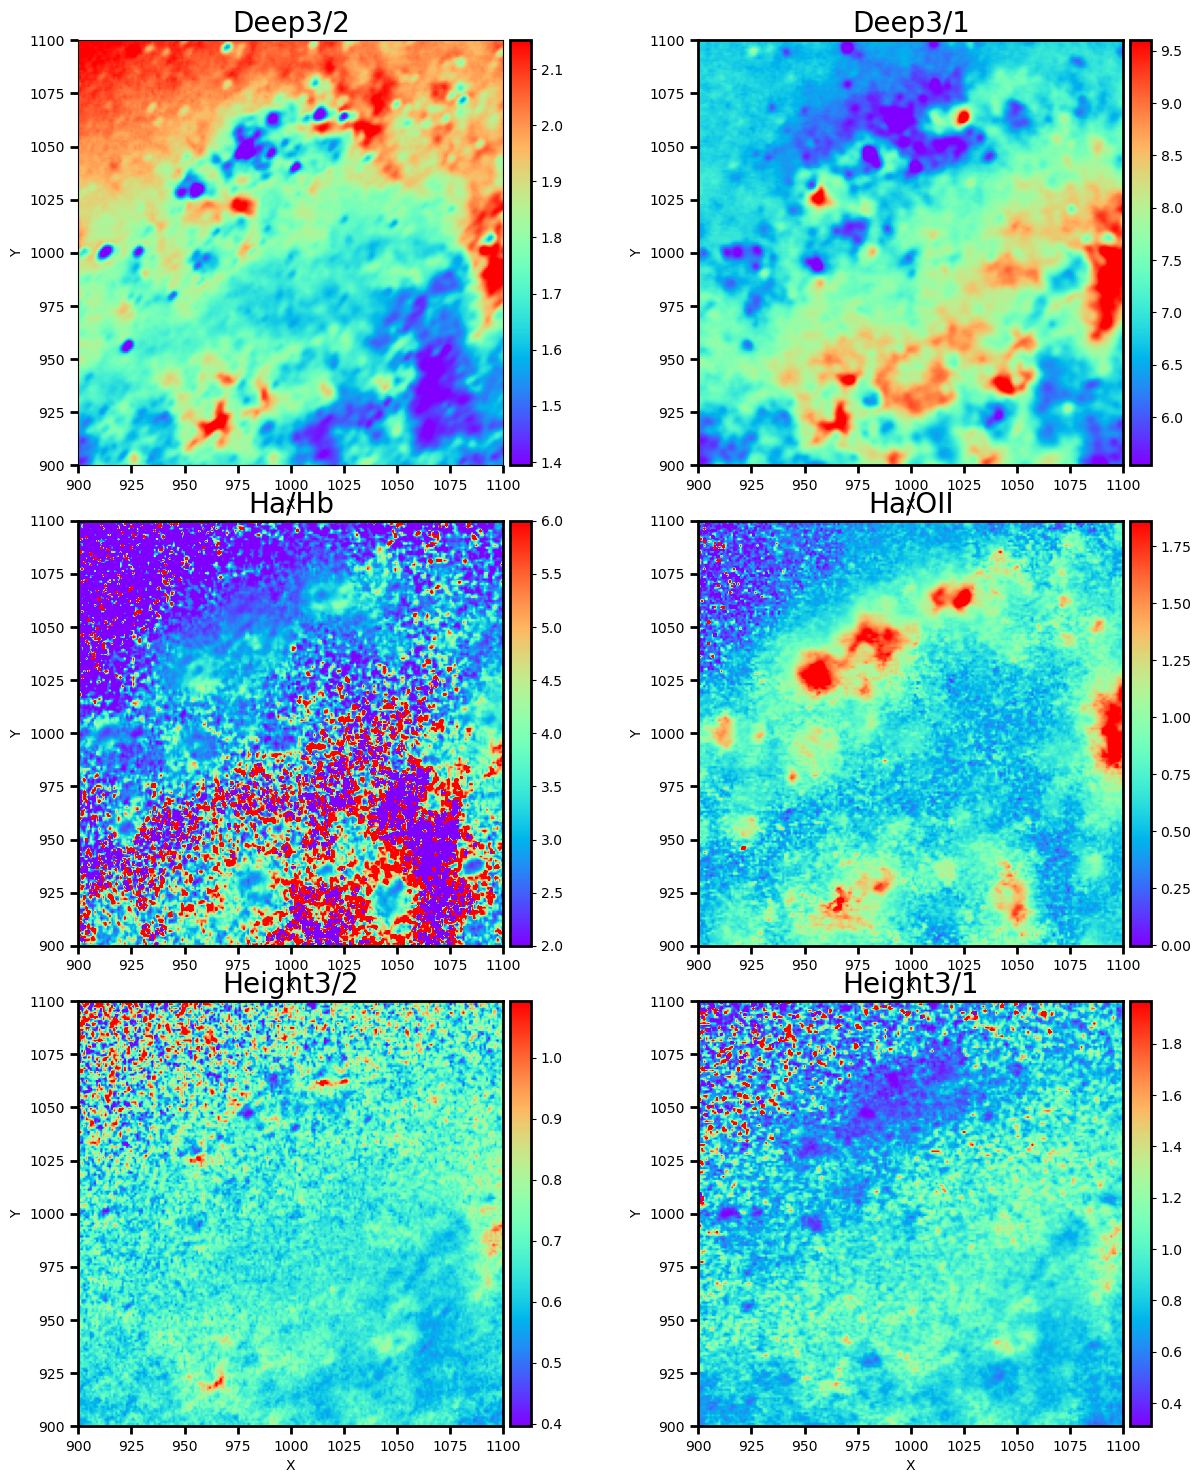

In [8]:
## To see

imfluxha         = fits.getdata(data_paths_dict['flux_Halpha'])
imcont3          = fits.getdata(data_paths_dict['continuum_SN3'])

%matplotlib inline

nyy, nxx, ip = 3,2, 0
fig1 = plt.figure(figsize=(8*nxx,6*nyy))
fig1.subplots_adjust(hspace=0.13,wspace=0.)

x3,y3,sizp = 1000,1000,100
xs1,xs2,ys1,ys2=int(x3)-sizp,int(x3)+sizp,int(y3)-sizp,int(y3)+sizp
alp=1
ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
imagein = imdeep3/imdeep2_alig
makeplot(0,1,imagein,imagein,xs1,xs2,ys1,ys2,alp,1,99)
plt.title('Deep3/2',size=20)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
imagein = imdeep3/imdeep1_alig
makeplot(0,1,imagein,imagein,xs1,xs2,ys1,ys2,alp,1,99)
plt.title('Deep3/1',size=20)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
imagein = imfluxha/imfluxhb_alig
makeplot(2,1,imagein,imagein,xs1,xs2,ys1,ys2,alp,2,6)
plt.title('Ha/Hb',size=20)


ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
imagein = imfluxha/imfluxo2_alig
makeplot(0,1,imagein,imagein,xs1,xs2,ys1,ys2,alp,1,99)
plt.title('Ha/OII',size=20)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
imagein = imcont3/imcont2_alig
makeplot(0,1,imagein,imagein,xs1,xs2,ys1,ys2,alp,1,99)
plt.title('Height3/2',size=20)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
imagein = imcont3/imcont1_alig
makeplot(0,1,imagein,imagein,xs1,xs2,ys1,ys2,alp,1,99)
plt.title('Height3/1',size=20)



In [8]:
# For noise 

gogo = 'no'   #Done 31 oct. 25 

if gogo == 'yes':
# SN1:
    alsol   = aligsol_SN1_transform
    header  = hdrdeep3
    folder  ='/users/carmellerobert/Desktop/NGC4490/1-DATA/'
    noise_sn1_alig  = aligmap(alsol,header,folder,'noise_SN1', 'NGC4490-SN1Noise_Aligned.fits')

# SN2:
    alsol   = aligsol_SN2_transform
    header  = hdrdeep3
    folder  ='/users/carmellerobert/Desktop/NGC4490/1-DATA/'
    noise_sn2_alig   = aligmap(alsol,header,folder,'noise_SN2', 'NGC4490-SN2Noise_Aligned.fits')
    

In json : noise_SN1_alig = /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-SN1Noise_Aligned.fits
New fits: /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-SN1Noise_Aligned.fits
In json : noise_SN2_alig = /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-SN2Noise_Aligned.fits
New fits: /users/carmellerobert/Desktop/NGC4490/1-DATA/NGC4490-SN2Noise_Aligned.fits
